In [1]:
from pathlib import Path
from os import environ

if "DRIVE_HOME" in environ:
  ROOT = Path(f"{environ.get("DRIVE_HOME")}/colab/outputs/waterloo-slt-reading-group")
else:
  ROOT = Path(f"{Path.cwd().parents[1]}/outputs")

basedir = Path(f"{ROOT}/mixture/poisson2d")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/posterior")


if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Created /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior!
Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior


In [23]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [24]:
def find_truth_by_dsid(dsid: str):
    dgp = dgps.query(f"dsid=='{dsid}'")
    truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
    return truth

In [26]:
from pymc_extensions.tempered_mixpoisson import TemperedPoissonMixture
from tqdm.notebook import tqdm
import pymc as pm
import numpy as np
import arviz as az

n_components = 2
n_trials = 100

regimes = [50, 250, 5000]
# regimes = [50]

n_draws = 1000
n_tune = 2500
posterior_data = {}

for dsid in tqdm(dgps["dsid"].unique(), desc=f"class "):
  posterior_data[dsid] = {}
  for regime in tqdm(regimes, desc=f"dsid={dsid}, regime "):
    # posterior_data_file = Path(f"{outputdir}/posterior-{dsid}-{regime}.nc")
    # if posterior_data_file.exists(): # check if this data has already been generated
        # idata = az.from_netcdf(posterior_data_file)
        # print(f"Loaded posterior data from {posterior_data_file}!")
  # else:
    dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")
    X = dataset.iloc[:, 0].to_numpy()
    # Mixture of 2 Poisson variables
    with TemperedPoissonMixture(X=X, beta=1, mus_log_prior_sigma=2) as model:
      idata = model.sample(draws=n_draws, tune=n_tune)  # or "blackjax"
      idata.to_netcdf(posterior_data_file)
      print(f"File {posterior_data_file} created!.")
      
    posterior_data[dsid][regime]=idata 

class :   0%|          | 0/4 [00:00<?, ?it/s]

dsid=regular, regime :   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

...

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular2-5000.nc created!.


In [22]:
posterior_data

{'regular': {5000: Inference data with groups:
  	> posterior
  	> sample_stats},
 'e-singular': {5000: Inference data with groups:
  	> posterior
  	> sample_stats},
 'singular1': {5000: Inference data with groups:
  	> posterior
  	> sample_stats},
 'singular2': {5000: Inference data with groups:
  	> posterior
  	> sample_stats}}

In [8]:
def chain_diag(dsid="singular1", regime=5000):
  az.plot_trace(posterior_data[dsid][regime], combined=True)

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot3d(dsid="singular1", regime=5000):
  idata = posterior_data[dsid][regime]
  w = idata.posterior["weights"][1,:,0]
  p0 = idata.posterior["mus"][1,:,0]
  p1 = idata.posterior["mus"][1,:,1]
  
  fig = plt.figure(figsize=(12, 10))  # width, height in inches
  ax = fig.add_subplot(111, projection='3d')
  
  n_chains = idata.posterior.dims["chain"]
  n_draws = idata.posterior.dims["draw"]
  markers = ['o', '^', '.', '+']
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain,:,0]
    p0 = idata.posterior["mus"][chain,:,0]
    p1 = idata.posterior["mus"][chain,:,1]
    ax.scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)

In [9]:
chain_diag("regular", 5000)

NameError: name 'chain_diag' is not defined

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ ($\mu_1=15$)',
    'e-singular': r'$m_2$ ($\mu_1=10$)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',
}

# Choose which beta to plot (e.g., beta=1 for untempered)
plot_beta = 1

n_regimes = len(regimes)

# --- Plot 1: Regular and Singular ---
reg_sing_dsids = ['regular', 'singular1']
reg_sing_dsids = [d for d in reg_sing_dsids if d in tempered_posterior_data]

fig1, axes1 = plt.subplots(len(reg_sing_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(reg_sing_dsids)), 
                            subplot_kw={'projection': '3d'})
if len(reg_sing_dsids) == 1:
    axes1 = axes1.reshape(1, -1)

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

markers = ['o', '^', '.', '+']

for i, dsid in enumerate(reg_sing_dsids):
    for j, regime in enumerate(regimes):
        idata = tempered_posterior_data[dsid][regime][plot_beta]
        n_chains = idata.posterior.sizes["chain"]
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["mus"][chain, :, 0]
            p1 = idata.posterior["mus"][chain, :, 1]
            axes1[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
        
        # Zoom in
        axes1[i, j].set_xlim(4, 16)
        axes1[i, j].set_ylim(4, 16)
        axes1[i, j].set_zlim(0, 1)
        
        # Original default angle
        axes1[i, j].view_init(elev=30, azim=-60)
        
        axes1[i, j].tick_params(labelsize=8)
        
        # Column titles only on top row
        if i == 0:
            axes1[i, j].set_title(f'n={regime}', fontsize=11)

# Add row labels on the right side
for i, dsid in enumerate(reg_sing_dsids):
    ax = axes1[i, -1]
    ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
              transform=ax.transAxes, 
              rotation=270, 
              va='center', 
              fontsize=11)

fig1.suptitle('Regular and Singular Posterior Geometry', fontsize=14, y=0.96)
fig1.savefig(Path(f"{outputdir}/3d_view_reg_sing.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Quasi-singular ---
quasi_dsids = ['e-singular']
quasi_dsids = [d for d in quasi_dsids if d in tempered_posterior_data]

if quasi_dsids:
    fig2, axes2 = plt.subplots(len(quasi_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(quasi_dsids)), 
                                subplot_kw={'projection': '3d'})
    if len(quasi_dsids) == 1:
        axes2 = axes2.reshape(1, -1)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

    for i, dsid in enumerate(quasi_dsids):
        for j, regime in enumerate(regimes):
            idata = tempered_posterior_data[dsid][regime][plot_beta]
            n_chains = idata.posterior.sizes["chain"]
            
            for chain in range(n_chains):
                w = idata.posterior["weights"][chain, :, 0]
                p0 = idata.posterior["mus"][chain, :, 0]
                p1 = idata.posterior["mus"][chain, :, 1]
                axes2[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
            
            # Zoom in
            axes2[i, j].set_xlim(4, 16)
            axes2[i, j].set_ylim(4, 16)
            axes2[i, j].set_zlim(0, 1)
            
            # Original default angle
            axes2[i, j].view_init(elev=30, azim=-60)
            
            axes2[i, j].tick_params(labelsize=8)
            
            # Column titles only on top row
            if i == 0:
                axes2[i, j].set_title(f'n={regime}', fontsize=11)

    # Add row labels on the right side
    for i, dsid in enumerate(quasi_dsids):
        ax = axes2[i, -1]
        ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
                  transform=ax.transAxes, 
                  rotation=270, 
                  va='center', 
                  fontsize=11)

    fig2.suptitle('Quasi-Singular Posterior Geometry', fontsize=14, y=0.96)
    fig2.savefig(Path(f"{outputdir}/3d_view_quasi.png"), dpi=600, bbox_inches="tight")
    plt.show()

NameError: name 'tempered_posterior_data' is not defined

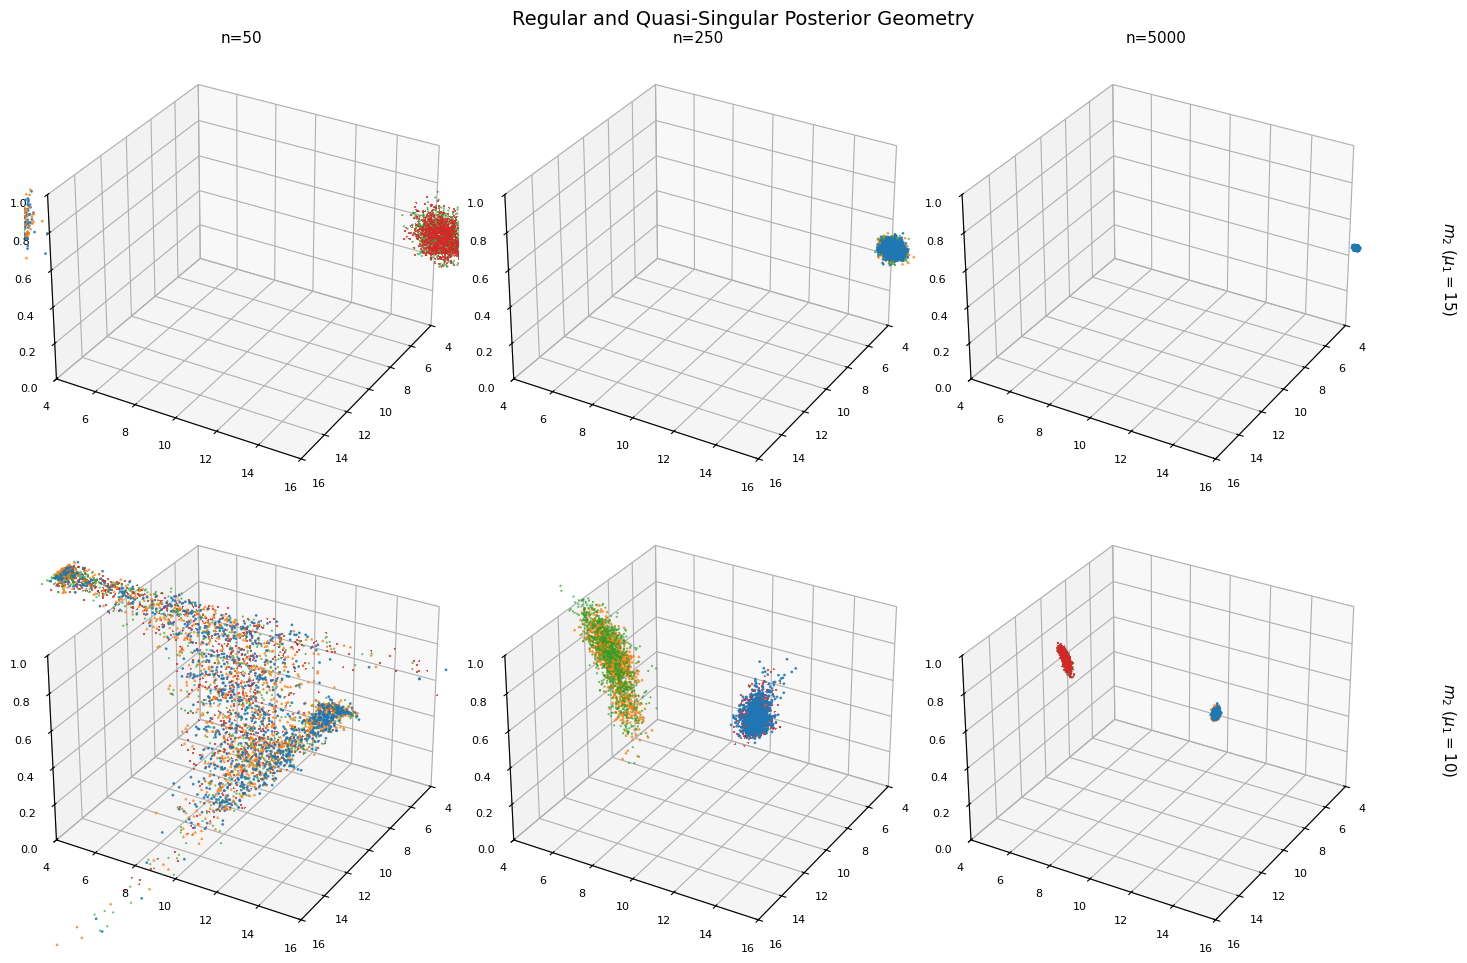

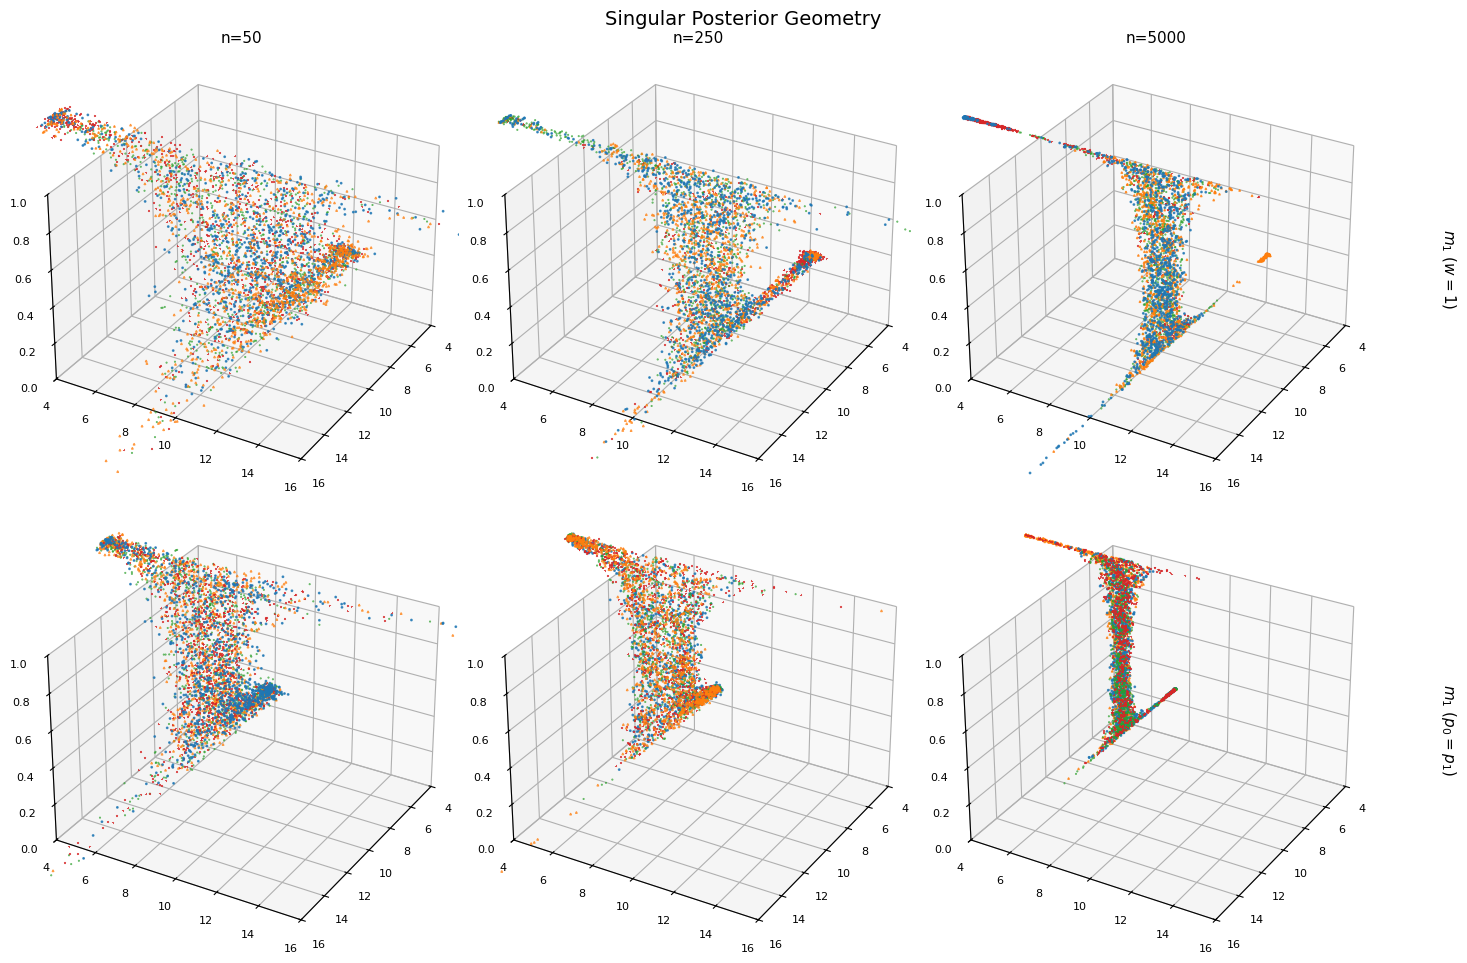

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ ($\mu_1=15$)',
    'e-singular': r'$m_2$ ($\mu_1=10$)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',
}

# Get regime names (sample sizes)
regime_names = list(list(posterior_data.values())[0].keys())
n_regimes = len(regime_names)

# --- Plot 1: Regular and Quasi-singular ---
quasi_dsids = ['regular', 'e-singular']
quasi_dsids = [d for d in quasi_dsids if d in posterior_data]

fig1, axes1 = plt.subplots(len(quasi_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(quasi_dsids)), 
                            subplot_kw={'projection': '3d'})
if len(quasi_dsids) == 1:
    axes1 = axes1.reshape(1, -1)

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

markers = ['o', '^', '.', '+']

for i, dsid in enumerate(quasi_dsids):
    for j, regime in enumerate(regime_names):
        idata = posterior_data[dsid][regime]
        n_chains = idata.posterior.sizes["chain"]
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["mus"][chain, :, 0]
            p1 = idata.posterior["mus"][chain, :, 1]
            axes1[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
        
        # Zoom in more
        axes1[i, j].set_xlim(4, 16)
        axes1[i, j].set_ylim(4, 16)
        axes1[i, j].set_zlim(0, 1)
        
        # Rotate 90 degrees to the right (increase azimuth)
        axes1[i, j].view_init(elev=30, azim=-60 + 90)
        
        axes1[i, j].tick_params(labelsize=8)
        
        # Column titles only on top row
        if i == 0:
            axes1[i, j].set_title(f'n={regime}', fontsize=11)

# Add row labels on the right side
for i, dsid in enumerate(quasi_dsids):
    ax = axes1[i, -1]
    ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
              transform=ax.transAxes, 
              rotation=270, 
              va='center', 
              fontsize=11)

fig1.suptitle('Regular and Quasi-Singular Posterior Geometry', fontsize=14, y=0.96)
fig1.savefig(Path(f"{outputdir}/3d_view_quasi.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Singular models ---
singular_dsids = ['singular1', 'singular2']
singular_dsids = [d for d in singular_dsids if d in posterior_data]

if singular_dsids:
    fig2, axes2 = plt.subplots(len(singular_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(singular_dsids)), 
                                subplot_kw={'projection': '3d'})
    if len(singular_dsids) == 1:
        axes2 = axes2.reshape(1, -1)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

    for i, dsid in enumerate(singular_dsids):
        for j, regime in enumerate(regime_names):
            idata = posterior_data[dsid][regime]
            n_chains = idata.posterior.sizes["chain"]
            
            for chain in range(n_chains):
                w = idata.posterior["weights"][chain, :, 0]
                p0 = idata.posterior["mus"][chain, :, 0]
                p1 = idata.posterior["mus"][chain, :, 1]
                axes2[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
            
            # Zoom in more
            axes2[i, j].set_xlim(4, 16)
            axes2[i, j].set_ylim(4, 16)
            axes2[i, j].set_zlim(0, 1)
            
            # Rotate 90 degrees to the right (increase azimuth)
            axes2[i, j].view_init(elev=30, azim=-60 + 90)
            
            axes2[i, j].tick_params(labelsize=8)
            
            # Column titles only on top row
            if i == 0:
                axes2[i, j].set_title(f'n={regime}', fontsize=11)

    # Add row labels on the right side
    for i, dsid in enumerate(singular_dsids):
        ax = axes2[i, -1]
        ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
                  transform=ax.transAxes, 
                  rotation=270, 
                  va='center', 
                  fontsize=11)

    fig2.suptitle('Singular Posterior Geometry', fontsize=14, y=0.96)
    fig2.savefig(Path(f"{outputdir}/3d_view_singular.png"), dpi=600, bbox_inches="tight")
    plt.show()

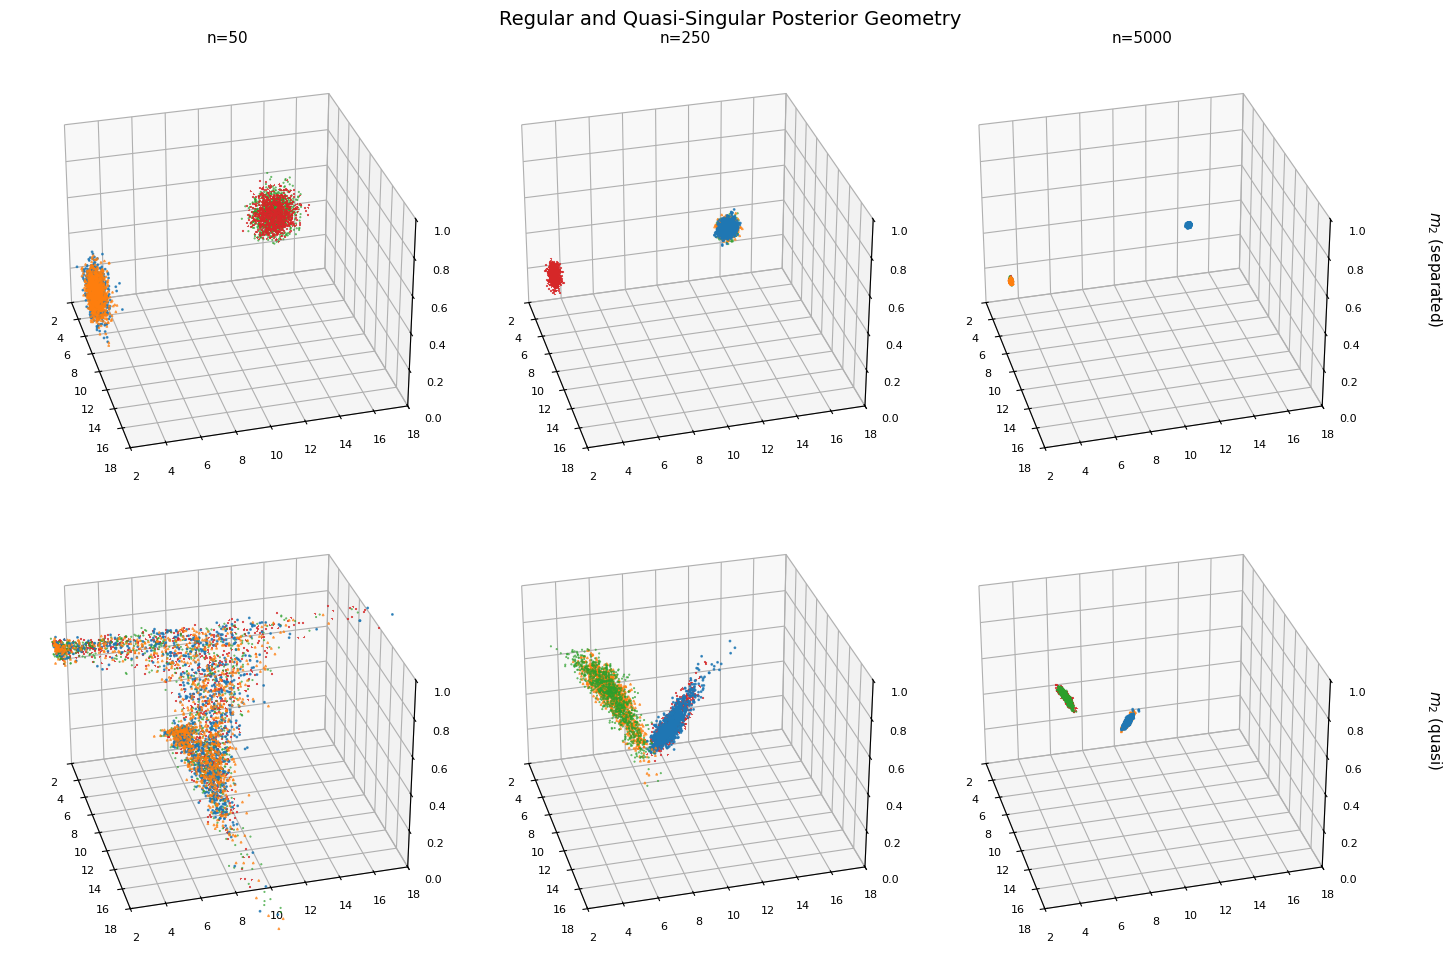

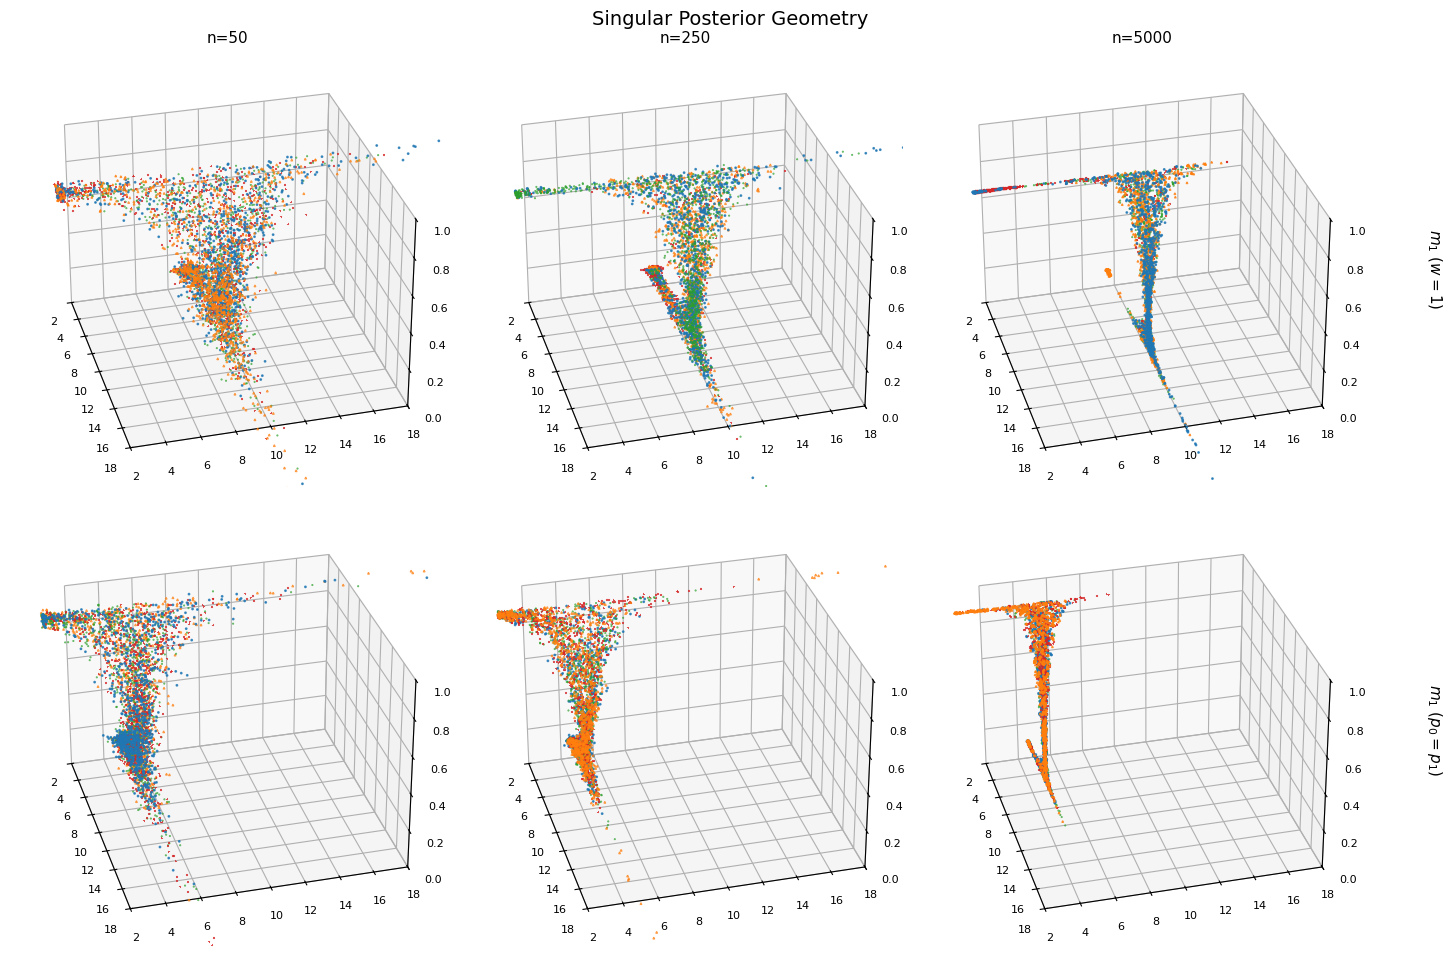

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ (separated)',
    'e-singular': r'$m_2$ (quasi)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',
}

# Get regime names (sample sizes)
regime_names = list(list(posterior_data.values())[0].keys())
n_regimes = len(regime_names)

# --- Plot 1: Regular and Quasi-singular ---
quasi_dsids = ['regular', 'e-singular']
quasi_dsids = [d for d in quasi_dsids if d in posterior_data]

fig1, axes1 = plt.subplots(len(quasi_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(quasi_dsids)), 
                            subplot_kw={'projection': '3d'})
if len(quasi_dsids) == 1:
    axes1 = axes1.reshape(1, -1)

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

markers = ['o', '^', '.', '+']

for i, dsid in enumerate(quasi_dsids):
    for j, regime in enumerate(regime_names):
        idata = posterior_data[dsid][regime]
        n_chains = idata.posterior.sizes["chain"]
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["mus"][chain, :, 0]
            p1 = idata.posterior["mus"][chain, :, 1]
            axes1[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
        
        # Zoom in
        axes1[i, j].set_xlim(2, 18)
        axes1[i, j].set_ylim(2, 18)
        axes1[i, j].set_zlim(0, 1)
        
        # Rotate 45 degrees to the right (increase azimuth)
        axes1[i, j].view_init(elev=30, azim=-60 + 45)
        
        axes1[i, j].tick_params(labelsize=8)
        
        # Column titles only on top row
        if i == 0:
            axes1[i, j].set_title(f'n={regime}', fontsize=11)

# Add row labels on the right side
for i, dsid in enumerate(quasi_dsids):
    ax = axes1[i, -1]
    ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
              transform=ax.transAxes, 
              rotation=270, 
              va='center', 
              fontsize=11)

fig1.suptitle('Regular and Quasi-Singular Posterior Geometry', fontsize=14, y=0.96)
fig1.savefig(Path(f"{outputdir}/3d_view_quasi.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Singular models ---
singular_dsids = ['singular1', 'singular2']
singular_dsids = [d for d in singular_dsids if d in posterior_data]

if singular_dsids:
    fig2, axes2 = plt.subplots(len(singular_dsids), n_regimes, figsize=(5 * n_regimes, 5 * len(singular_dsids)), 
                                subplot_kw={'projection': '3d'})
    if len(singular_dsids) == 1:
        axes2 = axes2.reshape(1, -1)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.92, top=0.92, bottom=0.02)

    for i, dsid in enumerate(singular_dsids):
        for j, regime in enumerate(regime_names):
            idata = posterior_data[dsid][regime]
            n_chains = idata.posterior.sizes["chain"]
            
            for chain in range(n_chains):
                w = idata.posterior["weights"][chain, :, 0]
                p0 = idata.posterior["mus"][chain, :, 0]
                p1 = idata.posterior["mus"][chain, :, 1]
                axes2[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
            
            # Zoom in
            axes2[i, j].set_xlim(2, 18)
            axes2[i, j].set_ylim(2, 18)
            axes2[i, j].set_zlim(0, 1)
            
            # Rotate 45 degrees to the right (increase azimuth)
            axes2[i, j].view_init(elev=30, azim=-60 + 45)
            
            axes2[i, j].tick_params(labelsize=8)
            
            # Column titles only on top row
            if i == 0:
                axes2[i, j].set_title(f'n={regime}', fontsize=11)

    # Add row labels on the right side
    for i, dsid in enumerate(singular_dsids):
        ax = axes2[i, -1]
        ax.text2D(1.15, 0.5, dsid_labels.get(dsid, dsid), 
                  transform=ax.transAxes, 
                  rotation=270, 
                  va='center', 
                  fontsize=11)

    fig2.suptitle('Singular Posterior Geometry', fontsize=14, y=0.96)
    fig2.savefig(Path(f"{outputdir}/3d_view_singular.png"), dpi=600, bbox_inches="tight")
    plt.show()

In [33]:
import plotly.graph_objects as go
import plotly.io as pio

def plot3dx(dsid="regular", regime=50):
  idata = posterior_data[dsid][regime]
  fig = go.Figure()
  
  markers = ['circle', 'diamond', 'square', 'cross']
  n_chains = idata.posterior.dims["chain"]
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain, :, 0].values
    p0 = idata.posterior["mus"][chain, :, 0].values
    p1 = idata.posterior["mus"][chain, :, 1].values
    
    fig.add_trace(go.Scatter3d(
        x=p0, y=p1, z=w,
        mode='markers',
        marker=dict(size=1, symbol=markers[chain]),
        name=f'Chain {chain}'
    ))
  
  fig.update_layout(
      scene=dict(
          xaxis_title='m0',
          yaxis_title='m1',
          zaxis_title='w'
      )
  )
  
  # For Jupyter notebooks
  pio.renderers.default = "notebook"
  # or
  # pio.renderers.default = "iframe"
  # or for JupyterLab
  # pio.renderers.default = "jupyterlab"
  fig.update_layout(
      width=1000,
      height=800
  )
  fig.show()

In [13]:
# plot3dx("singular2", 5000)

In [34]:
# put the posteriors in a dataframe for easy visualization
joined_posterior_data = []
for dsid, dd in posterior_data.items():
    truth = find_truth_by_dsid(dsid=dsid)
    # dgp_weights = dgp[["w0", "w1"]].iloc[0].tolist()
    # dgp_mus = dgp[["m0", "m1"]].iloc[0].tolist()
    # truth = np.concatenate([dgp_mus, dgp_weights])
    for ss in regimes:
    # for trial in tqdm(range(dd[ss].shape[1]), desc=f"{dsid}-{ss} trials "):
        # for trial in tqdm(range(100), desc=f"{dsid}-{ss} trials "):
        # X = dd[ss].iloc[:, trial].to_numpy()
        # X = X.reshape(len(X), 1)
        # model._initialize_parameters(
            # X, rng
        # )  # cold reinitialization to force identifiability issues
        # model.fit(X)
        # mle, mle_detail = model.point_estimate()
        # fisher_mat = model.fisher_matrix(X)
      idata = dd[ss]
      param_samples = az.extract(idata, var_names=["weights", "mus"])
      n_draws = param_samples.sizes["sample"]
      joined_posterior_data.append({
        "w0": param_samples["weights"][0,].values,
        "m0": param_samples["mus"][0,].values,
        "m1": param_samples["mus"][1,].values,
        "n": np.repeat(ss, n_draws),
        "dsid": np.repeat(dsid, n_draws),
      })

joined_posterior_df = pd.concat([pd.DataFrame(d) for d in joined_posterior_data], ignore_index=True)
joined_posterior_df.head()

,w0,m0,m1,n,dsid
0,0.787149,14.883021,1.157616,50,regular
1,0.778352,14.831755,1.057425,50,regular
2,0.537440,14.838810,1.670185,50,regular
3,0.634685,15.465725,1.056887,50,regular
4,0.687003,15.195582,1.154847,50,regular


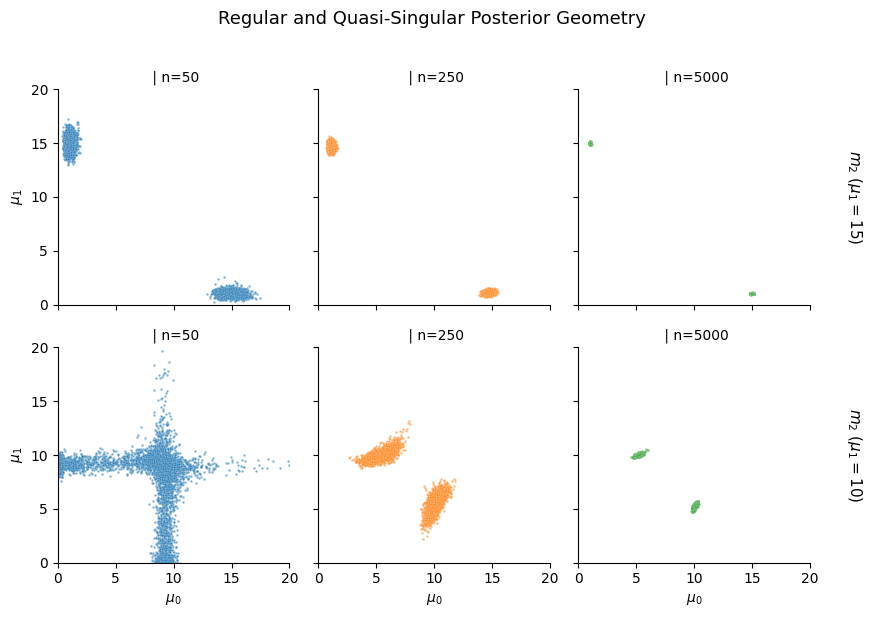

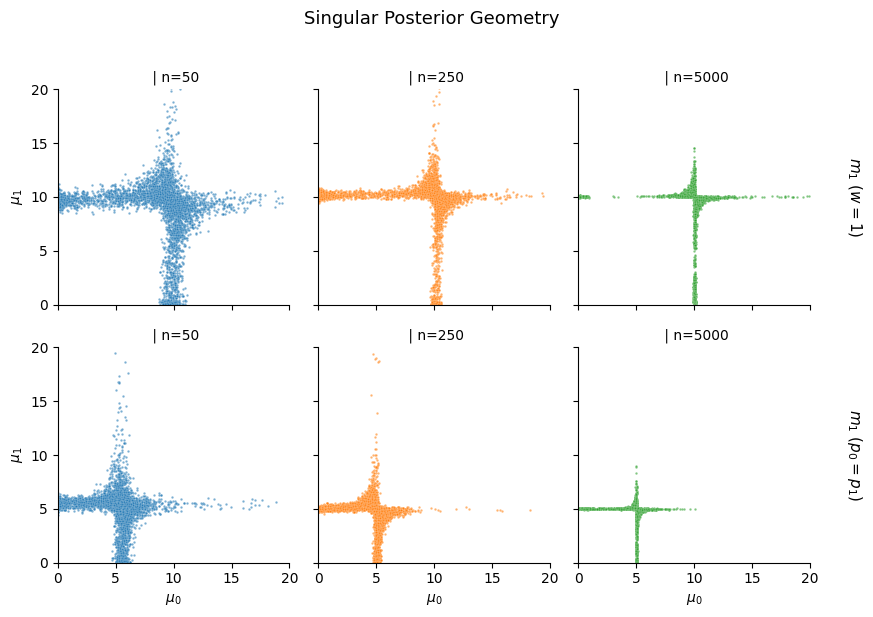

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label mapping for display
dsid_labels = {
    'regular': r'$m_2$ ($\mu_1=15$)',
    'e-singular': r'$m_2$ ($\mu_1=10$)',
    'singular1': r'$m_1$ ($w=1$)',
    'singular2': r'$m_1$ ($p_0=p_1$)',
}

# Color palette for sample sizes - using tab10 colors (brighter)
tab10 = sns.color_palette("tab10")
n_palette = {
    50: tab10[0],      # blue
    250: tab10[1],     # orange
    5000: tab10[2],    # green
}

# Or if you want even brighter, try Set1:
# set1 = sns.color_palette("Set1")
# n_palette = {
#     50: set1[1],      # blue
#     250: set1[4],     # orange
#     5000: set1[2],    # green
# }

# --- Plot 1: Regular and Quasi-singular ---
quasi_df = joined_posterior_df[joined_posterior_df['dsid'].isin(['regular', 'e-singular'])]

g1 = sns.FacetGrid(quasi_df, row="dsid", col="n", height=3, aspect=1)
g1.map_dataframe(lambda data, **kwargs: sns.scatterplot(data=data, x="m0", y="m1", 
                                                         color=n_palette.get(data['n'].iloc[0], 'gray'),
                                                         alpha=0.6, s=3))
g1.set(xlim=(0, 20), ylim=(0, 20))
g1.set_axis_labels(r"$\mu_0$", r"$\mu_1$")
g1.set_titles(col_template="n={col_name}", row_template="")

# Add row labels on the right side
for i, dsid_val in enumerate(g1.row_names):
    ax = g1.axes[i, -1]
    ax.text(1.15, 0.5, dsid_labels.get(dsid_val, dsid_val), 
            transform=ax.transAxes, 
            rotation=270, 
            va='center', 
            fontsize=11)

g1.figure.suptitle('Regular and Quasi-Singular Posterior Geometry', y=1.02, fontsize=13)
plt.tight_layout()
plt.subplots_adjust(right=0.92)
plt.savefig(Path(f"{outputdir}/2d_view_quasi.png"), dpi=600, bbox_inches="tight")
plt.show()


# --- Plot 2: Singular models ---
singular_dsids = ['singular1', 'singular2']
singular_df = joined_posterior_df[joined_posterior_df['dsid'].isin(singular_dsids)]

if len(singular_df) > 0:
    g2 = sns.FacetGrid(singular_df, row="dsid", col="n", height=3, aspect=1)
    g2.map_dataframe(lambda data, **kwargs: sns.scatterplot(data=data, x="m0", y="m1", 
                                                             color=n_palette.get(data['n'].iloc[0], 'gray'),
                                                             alpha=0.6, s=3))
    g2.set(xlim=(0, 20), ylim=(0, 20))
    g2.set_axis_labels(r"$\mu_0$", r"$\mu_1$")
    g2.set_titles(col_template="n={col_name}", row_template="")

    # Add row labels on the right side
    for i, dsid_val in enumerate(g2.row_names):
        ax = g2.axes[i, -1]
        ax.text(1.15, 0.5, dsid_labels.get(dsid_val, dsid_val), 
                transform=ax.transAxes, 
                rotation=270, 
                va='center', 
                fontsize=11)

    g2.figure.suptitle('Singular Posterior Geometry', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.subplots_adjust(right=0.92)
    plt.savefig(Path(f"{outputdir}/2d_view_singular.png"), dpi=600, bbox_inches="tight")
    plt.show()

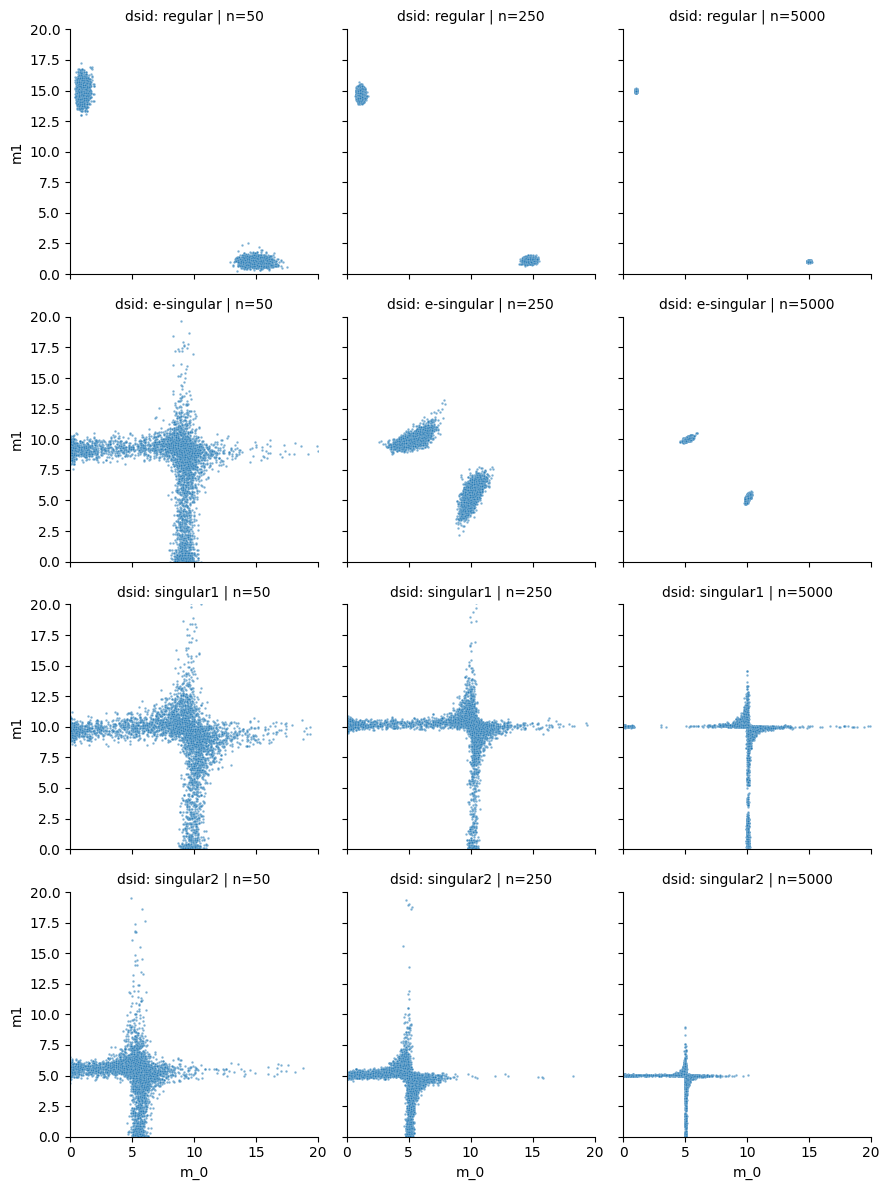

In [35]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m0", "m1", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 20))
# Add labels and formatting
g.set_axis_labels("m_0", "m1")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
plt.show()

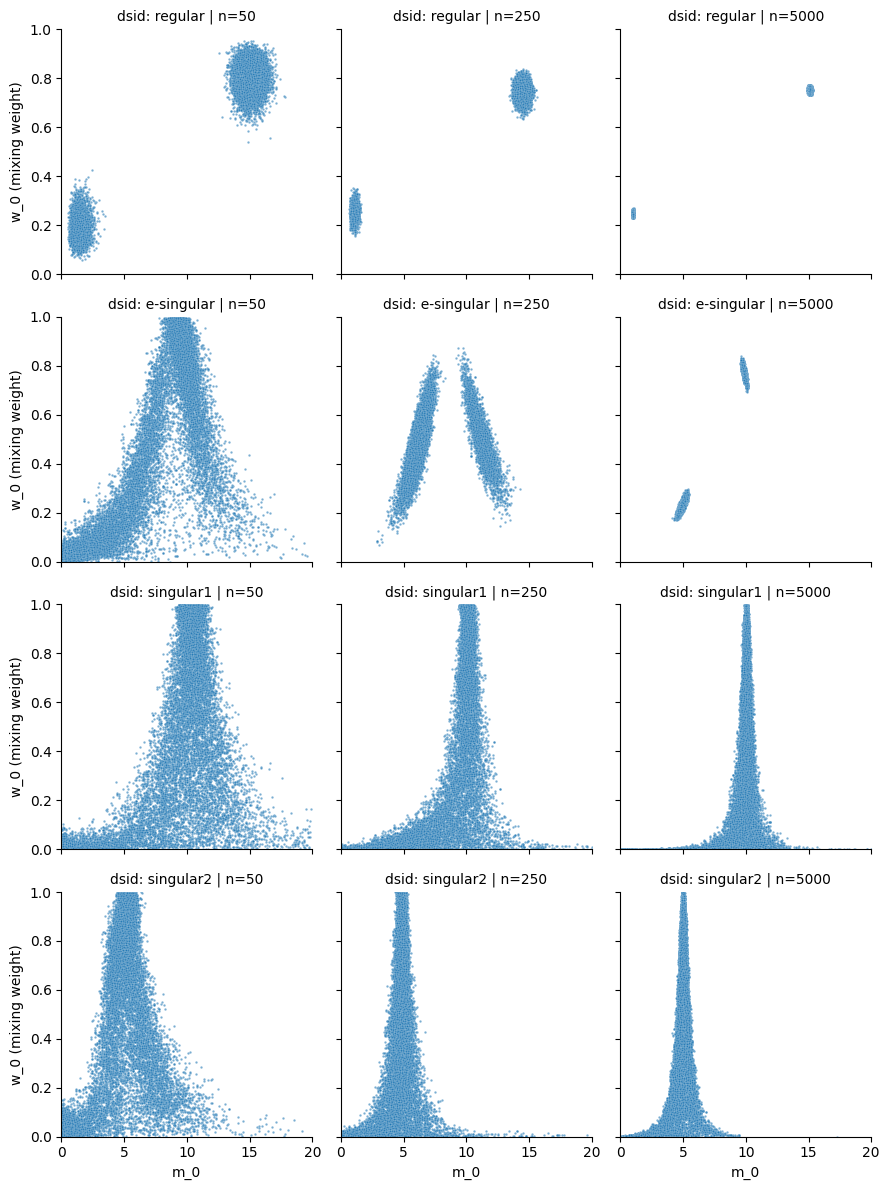

In [20]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m0", "w0", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 1))
# Add labels and formatting
g.set_axis_labels("m_0", "w_0 (mixing weight)")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
plt.show()

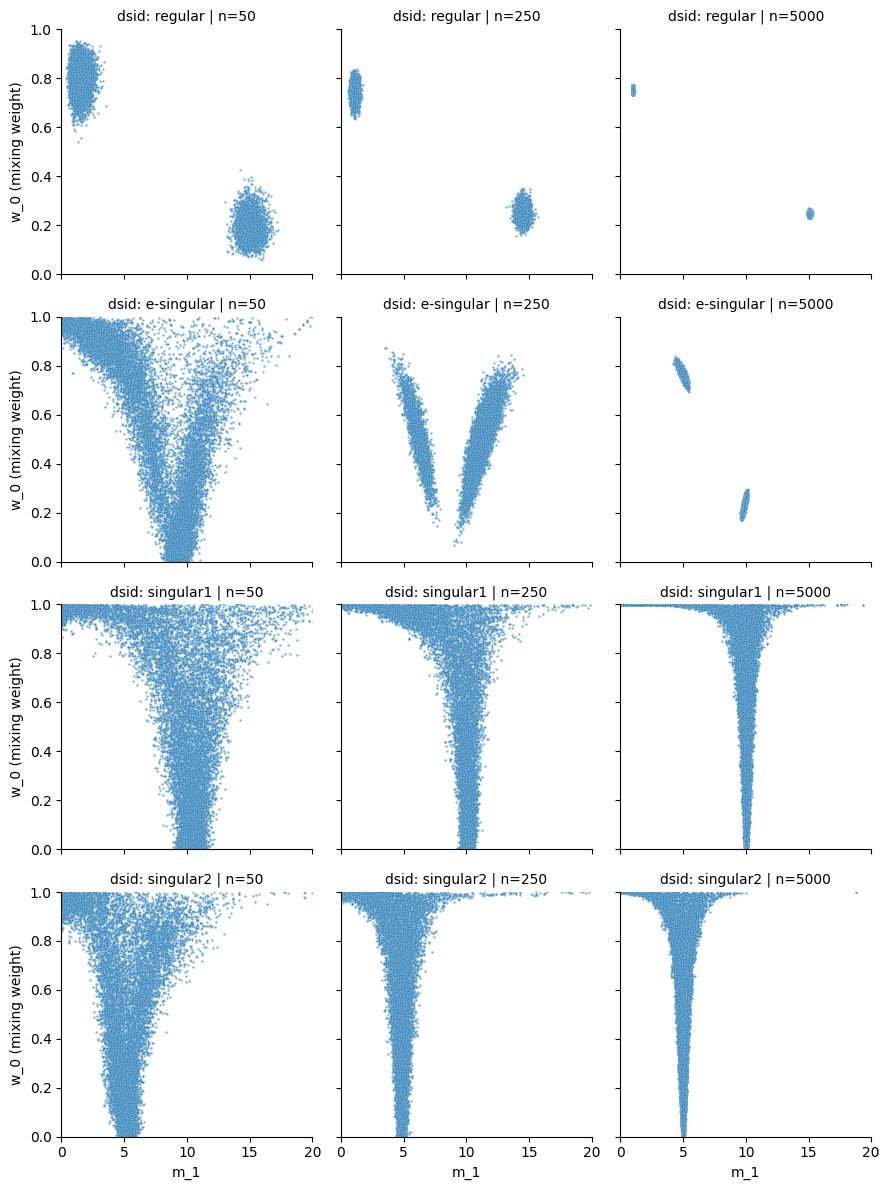

In [21]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m1", "w0", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 1))
# Add labels and formatting
g.set_axis_labels("m_1", "w_0 (mixing weight)")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
plt.show()

In [22]:
def clean_for_plotting(
    arr, method="percentile", threshold=1000, percentile=95, handle_nan=True, clip=True
):
    """
    Universal cleaning function for plotting

    Parameters:
    -----------
    arr : array-like
    method : 'percentile' or 'threshold'
        How to determine replacement values
    threshold : float
        For 'threshold' method: distance from min/max
    percentile : float
        For 'percentile' method: which percentile to use
    handle_nan : bool
        Whether to replace NaN
    clip : bool
        Whether to clip to [min, max] range
    """
    arr = np.asarray(arr, dtype=float).copy()

    finite_mask = np.isfinite(arr)

    if not np.any(finite_mask):
        return np.zeros_like(arr)

    finite_values = arr[finite_mask]

    if method == "percentile":
        low_val = np.percentile(finite_values, 100 - percentile)
        high_val = np.percentile(finite_values, percentile)
        value_range = high_val - low_val
        margin = max(value_range * 0.1, abs(high_val) * 0.01, 1.0)
        replacement_low = low_val - margin
        replacement_high = high_val + margin
    else:  # threshold
        finite_min = finite_values.min()
        finite_max = finite_values.max()
        replacement_low = finite_min - threshold
        replacement_high = finite_max + threshold

    # Replace infinities
    arr = np.where(np.isneginf(arr), replacement_low, arr)
    arr = np.where(np.isposinf(arr), replacement_high, arr)

    if handle_nan:
        arr = np.where(np.isnan(arr), replacement_high, arr)

    if clip:
        arr = np.clip(arr, replacement_low, replacement_high)

    return arr

In [ ]:
def plot_kl_contours(data_df, profile_kl, plot_options={}, profile_options={}):
    plot_options = {
        "quantiles": np.array(
            [
                0.01,
                0.02,
                0.03,
                0.04,
                0.05,
                0.075,
                0.9,
                0.1,
                0.2,
                0.3,
                0.4,
                0.5,
                0.6,
                0.7,
                0.8,
                0.9,
                0.99,
            ]
        ),
        # "colors": ['#808080', '#A0A0A0', '#C0C0C0'],
        "figsize": (16, 6),
        "linewidths": 2.0,
        "cmap": "magma",
        "line_colors": "black",
        "label_fontsize": 1000,
    } | plot_options

    profile_options = {"grid_size": 100} | profile_options

    # Get unique values for facets
    dsids = data_df["dsid"].unique()
    n_obs_list = sorted(data_df["n"].unique())

    n_rows = len(dsids)
    n_cols = len(n_obs_list)

    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10), sharex=True, sharey=True)

    # Plot each panel
    for i, dsid in enumerate(tqdm(dsids, desc=f"datasets ")):
        # for i, dsid in enumerate(dsids):
        dgp = dgps.query(f"dsid=='{dsid}'")
        truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
        height = profile_kl(
            n_components=n_components,
            n_trials=n_trials,
            truth=truth,
            x_param={"name": "probs", "index": 0},
            y_param={"name": "probs", "index": 1},
            profile_grid_size=profile_options["grid_size"],
        )

        for j, n in enumerate(tqdm(sample_sizes, desc=f"{dsid} figures")):
            ax = axes[i, j]

            # Filter data for this combination
            subset = mles_df[(mles_df["dsid"] == dsid) & (mles_df["n"] == n)]

            # 1. computed profile KL values
            x = np.linspace(0, 1, 50)
            y = np.linspace(0, 1, 50)
            X, Y = np.meshgrid(x, y)
            Z = height(X, Y)

            # compoute contour levels for the quantiles
            # Z = clean_for_plotting(height(X,Y), method='percentile', percentile=0.999)
            levels = np.unique(np.quantile(Z, plot_options["quantiles"]))

            # align contours with levels
            n_levels = len(levels)
            cmap = plt.get_cmap("YlOrRd")
            colors = [cmap(q) for q in np.linspace(0, 1, n_levels)]

            cs = ax.contourf(
                X, Y, Z, levels=levels, colors=colors, alpha=0.8, extend="both"
            )
            cs_lines = ax.contour(X, Y, Z, levels=levels, colors="black", linewidths=1)
            # Create a dictionary mapping each level to its corresponding quantile value
            fmt = {}
            for l, level in enumerate(levels):
                if l < len(plot_options["quantiles"]):
                    # Just show the quantile value (e.g., "0.95")
                    fmt[level] = f"{plot_options['quantiles'][l]:.2f}"

            # Apply the custom labels
            ax.clabel(
                cs_lines,
                fontsize=6,
                inline=True,
                fmt=fmt,
                inline_spacing=10,
                colors="black",
                use_clabeltext=True,
            )

            # Scatter plot
            sns.scatterplot(data=subset, x="p0", y="p1", ax=ax, alpha=1, s=5)

            # Add title
            if i == 0:
                ax.set_title(f"n={n}", fontweight="bold")
            if j == 0:
                ax.set_ylabel(f"dsid: {dsid}\np_0", fontweight="bold")
            else:
                ax.set_ylabel("p_1")

            if i == n_rows - 1:
                ax.set_xlabel("p_0")
            else:
                ax.set_xlabel("")
            # break
        # break
    return fig, axes


fig, axes = plot_kl_contours(
    mles_df, profile_kl=create_mixbinom_profile_kl, profile_options={"grid_size": 20}
)

plt.tight_layout()
fig.savefig(Path(f"{basedir}/mle/mles_with_kl.png"), dpi=600, bbox_inches="tight")
plt.show()